# Trabalho de KDD: Análise de Rede no Reddit (Tema: Redpill)
**Objetivo:** Aplicar a metodologia KDD (Knowledge Discovery in Databases) em uma base de dados real coletada do Reddit utilizando a técnica de Snowballing.

## 1. Importação de Bibliotecas

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import re
import itertools

# Configuração visual padrão para os gráficos
sns.set_theme(style="whitegrid")

## 2. Coleta e Carregamento dos Dados

In [5]:
rows = []
erros = []

# Itera por cada profundidade
for depth in range(3 + 1):
    dir_ = f"../data/raw/{depth}/subreddits"
    if not os.path.exists(dir_):
        continue
    for filename in os.listdir(dir_):
        if filename.endswith(".json"):
            path = os.path.join(dir_, filename)
            try:
                with open(path, "r", encoding="utf-8") as f:
                    posts = json.load(f)
                # Adiciona a profundidade em cada post para rastreabilidade
                for post in posts:
                    post["depth"] = depth
                rows.extend(posts)
            except json.JSONDecodeError:
                erros.append(path)

print(f"Arquivos com erro: {len(erros)}")
print(f"Posts carregados: {len(rows)}")

df = pd.DataFrame(rows)
display(df)

Arquivos com erro: 0
Posts carregados: 843859


,id,title,author,subreddit,timestamp,score,comments_text,url,depth
0,t3_1rxwu2i,"What 1,700 Studies on Domestic Violence Actual...",FluidWrangler3666,mensrights,2026-03-19T10:31:53+00:00,53,12 comments,https://open.substack.com/pub/hiddenvictims/p/...,0
1,t3_1pl570n,Mental Health Support worldwide,iainmf,mensrights,2025-12-12T22:31:39+00:00,29,4 comments,/r/MensRights/comments/1pl570n/mental_health_s...,0
2,t3_1saogmm,UK: Police given stronger powers to combat pub...,furchfur,mensrights,2026-04-02T17:49:30+00:00,148,UK: Police given stronger powers to combat pub...,https://news.sky.com/story/police-given-strong...,0
3,t3_1saekz2,Watch how a male victim gets bashed for highli...,FluidWrangler3666,mensrights,2026-04-02T11:19:18+00:00,219,23 comments,https://www.reddit.com/r/TrueOffMyChest/commen...,0
4,t3_1sahkk0,All of feminism boils down to women being upse...,No_Road5857,mensrights,2026-04-02T13:34:43+00:00,135,8 comments,/r/MensRights/comments/1sahkk0/all_of_feminism...,0
...,...,...,...,...,...,...,...,...,...
843854,t3_1s9ojbk,Humiliated Trump Watches Own Justices Tear His...,spherocytes,politics,2026-04-01T15:54:45+00:00,3701,120 comments,https://www.thedailybeast.com/humiliated-trump...,2
843855,t3_1sasmls,Drugmakers face 100% tariff unless they cut pr...,RolePsychological890,politics,2026-04-02T20:23:24+00:00,18,14 comments,https://www.reuters.com/sustainability/boards-...,2
843856,t3_1s9yuvn,Trump Says There’s No Money for Daycare Becaus...,Hafiz_TNR,politics,2026-04-01T22:00:17+00:00,1126,114 comments,https://newrepublic.com/post/208523/trump-no-m...,2
843857,t3_1s9pspf,Top FEMA Official Doubles Down on Claim He Tel...,Hafiz_TNR,politics,2026-04-01T16:38:52+00:00,3028,415 comments,https://newrepublic.com/post/208460/fema-offic...,2


In [6]:
print(f"Quantidade de subreddits únicos: {df['subreddit'].nunique()}")
print(f"Quantidade de autores únicos: {df['author'].nunique()}")
print(f"Quantidade de posts carregados: {len(df)}")

Quantidade de subreddits únicos: 4454
Quantidade de autores únicos: 494132
Quantidade de posts carregados: 843859


## 3. Engenharia de Atributos
A partir dos textos e *timestamps* brutos, precisamos gerar variáveis numéricas que os modelos matemáticos e gráficos consigam interpretar.
1. `titleSize`: Tamanho do título em palavras.
2. `titleChars`: Tamanho do título em caracteres.
2. `tem_hashtag`: Flag que analisa se tem hashtag no título.
2. `tem_url`: Flag que analisa se tem URL no título.
2. `commentsCount`: Extração apenas do número de comentários.
2. `data`: Data da postagem.
2. `hora_exata`: Hora exata da postagem.
3. `hora_num`: Hora do dia em que o post foi feito (0 a 23).

In [7]:
df['titleSize'] = df['title'].astype(str).apply(lambda x: len(x.split()))
df['titleChars'] = df['title'].astype(str).apply(len)

df['tem_hashtag'] = df['title'].astype(str).str.contains(r'#', na=False)
df['tem_url'] = df['title'].astype(str).str.contains(r'http|www\.', flags=re.IGNORECASE, na=False)

df['tem_hashtag'] = df['tem_hashtag'].astype(int)
df['tem_url'] = df['tem_url'].astype(int)

df['commentsCount'] = df['comments_text'].str.extract(r'(\d+)').astype(float)
df['score'] = pd.to_numeric(df['score'], errors='coerce')

df['timestamp'] = pd.to_datetime(df['timestamp'])
df['data'] = df['timestamp'].dt.date
df['hora_exata'] = df['timestamp'].dt.time
df['hora_num'] = df['timestamp'].dt.hour

display(df)

,id,title,author,subreddit,timestamp,score,comments_text,url,depth,titleSize,titleChars,tem_hashtag,tem_url,commentsCount,data,hora_exata,hora_num
0,t3_1rxwu2i,"What 1,700 Studies on Domestic Violence Actual...",FluidWrangler3666,mensrights,2026-03-19 10:31:53+00:00,53,12 comments,https://open.substack.com/pub/hiddenvictims/p/...,0,8,54,0,0,12.0,2026-03-19,10:31:53,10
1,t3_1pl570n,Mental Health Support worldwide,iainmf,mensrights,2025-12-12 22:31:39+00:00,29,4 comments,/r/MensRights/comments/1pl570n/mental_health_s...,0,4,31,0,0,4.0,2025-12-12,22:31:39,22
2,t3_1saogmm,UK: Police given stronger powers to combat pub...,furchfur,mensrights,2026-04-02 17:49:30+00:00,148,UK: Police given stronger powers to combat pub...,https://news.sky.com/story/police-given-strong...,0,32,169,0,0,NaN,2026-04-02,17:49:30,17
3,t3_1saekz2,Watch how a male victim gets bashed for highli...,FluidWrangler3666,mensrights,2026-04-02 11:19:18+00:00,219,23 comments,https://www.reddit.com/r/TrueOffMyChest/commen...,0,13,76,0,0,23.0,2026-04-02,11:19:18,11
4,t3_1sahkk0,All of feminism boils down to women being upse...,No_Road5857,mensrights,2026-04-02 13:34:43+00:00,135,8 comments,/r/MensRights/comments/1sahkk0/all_of_feminism...,0,20,101,0,0,8.0,2026-04-02,13:34:43,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
843854,t3_1s9ojbk,Humiliated Trump Watches Own Justices Tear His...,spherocytes,politics,2026-04-01 15:54:45+00:00,3701,120 comments,https://www.thedailybeast.com/humiliated-trump...,2,10,69,0,0,120.0,2026-04-01,15:54:45,15
843855,t3_1sasmls,Drugmakers face 100% tariff unless they cut pr...,RolePsychological890,politics,2026-04-02 20:23:24+00:00,18,14 comments,https://www.reuters.com/sustainability/boards-...,2,13,73,0,0,14.0,2026-04-02,20:23:24,20
843856,t3_1s9yuvn,Trump Says There’s No Money for Daycare Becaus...,Hafiz_TNR,politics,2026-04-01 22:00:17+00:00,1126,114 comments,https://newrepublic.com/post/208523/trump-no-m...,2,13,69,0,0,114.0,2026-04-01,22:00:17,22
843857,t3_1s9pspf,Top FEMA Official Doubles Down on Claim He Tel...,Hafiz_TNR,politics,2026-04-01 16:38:52+00:00,3028,415 comments,https://newrepublic.com/post/208460/fema-offic...,2,12,69,0,0,415.0,2026-04-01,16:38:52,16


Normalização de valores para futuras análises

In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

colunas_para_normalizar = ['score', 'commentsCount', 'titleSize', 'titleChars']
colunas_normalizadas = [col + '_norm' for col in colunas_para_normalizar]

df[colunas_normalizadas] = scaler.fit_transform(df[colunas_para_normalizar])

print("--- DADOS NORMALIZADOS (ESCALA DE 0 A 1) ---")
display(df[colunas_normalizadas].describe().round(4))

ModuleNotFoundError: No module named 'sklearn'

## 4. Limpeza de Dados (Data Cleaning)

In [ ]:
dados_bizarros = df[df['commentsCount'] > 100000]
print(f"Encontrados {len(dados_bizarros)} registros com contagem bizarra de comentários.")

df = df[df['commentsCount'] <= 100000]

df_limpo = df.dropna(subset=['score', 'commentsCount'])

print("\n--- ESTATÍSTICAS APÓS LIMPEZA ---")
print(df_limpo[['score', 'commentsCount', 'titleSize', 'titleChars']].describe())

print("\n--- CONTAGEM: PRESENÇA DE HASHTAGS (0=Não, 1=Sim) ---")
print((df_limpo['tem_hashtag'].value_counts(normalize=True) * 100).round(2).astype(str) + '%')

print("\n--- CONTAGEM: PRESENÇA DE URLs (0=Não, 1=Sim) ---")
print((df_limpo['tem_url'].value_counts(normalize=True) * 100).round(2).astype(str) + '%')

Encontrados 0 registros com contagem bizarra de comentários.

--- ESTATÍSTICAS APÓS LIMPEZA ---
               score  commentsCount      titleSize     titleChars
count  723514.000000  723514.000000  723514.000000  723514.000000
mean      279.837949      31.783652       8.855473      50.342161
std      1913.752543     223.270591       7.102975      40.431555
min         0.000000       0.000000       1.000000       1.000000
25%         3.000000       3.000000       4.000000      24.000000
50%        18.000000       8.000000       7.000000      40.000000
75%       101.000000      23.000000      11.000000      64.000000
max    236040.000000   83820.000000     148.000000     300.000000

--- CONTAGEM: PRESENÇA DE HASHTAGS (0=Não, 1=Sim) ---
tem_hashtag
0    99.55%
1     0.45%
Name: proportion, dtype: object

--- CONTAGEM: PRESENÇA DE URLs (0=Não, 1=Sim) ---
tem_url
0    99.98%
1     0.02%
Name: proportion, dtype: object


## 5. Rotulação e Filtragem do Domínio
Como usamos o *Snowballing*, as ramificações (`depth > 0`) podem se afastar do tema original. Vamos criar uma *flag* para classificar se o post ainda pertence ao universo léxico do tema "Redpill/Manosphere".

In [ ]:
KEYWORDS_RELEVANTES = [
    # Red pill / manosphere
    "redpill", "red pill", "blackpill", "black pill", "bluepill", "blue pill",
    "mgtow", "incel", "hypergamy", "pickup", "pua", "mens rights",
    "trp", "manosphere", "looksmaxxing", "looksmax",

    # Gênero
    "women", "woman", "female", "male", "gender", "feminist", "feminism",
    "femininity", "masculinity", "tradwife", "trad wife",

    # Termos misóginos
    "femoid", "foid", "roastie", "stacy", "chad", "betabux",
    "alpha male", "beta male", "sigma male", "cock carousel",
    "sexual market value", "smv", "hypergamy",

    # Relacionamentos
    "dating", "relationship", "marriage", "divorce", "attraction",
    "tinder", "boyfriend", "girlfriend", "hookup",

    # Misoginia geral
    "inferior", "submissive", "obey", "belong",
]

def tem_keyword(title):
    if not isinstance(title, str):
        return False
    title_lower = title.lower()
    for kw in KEYWORDS_RELEVANTES:
        if kw in title_lower:
            return True
    return False

df['relevante'] = df['title'].apply(tem_keyword)

stats = df.groupby('depth')['relevante'].agg(['count', 'sum'])

stats['% relevante'] = (stats['sum'] / stats['count']) * 100
stats['fora_do_tema'] = stats['count'] - stats['sum']
stats['% fora_do_tema'] = (stats['fora_do_tema'] / stats['count']) * 100

for d in stats.index:
    print(f"___________________________________________________")
    print(f"Total de posts (depth={d})      : {stats.loc[d, 'count']}")
    print(f"Posts relevantes (depth={d})    : {stats.loc[d, 'sum']} ({stats.loc[d, '% relevante']:.1f}%)")
    print(f"Posts fora do tema (depth={d})  : {stats.loc[d, 'fora_do_tema']} ({stats.loc[d, '% fora_do_tema']:.1f}%)")

___________________________________________________
Total de posts (depth=0)      : 979
Posts relevantes (depth=0)    : 335 (34.2%)
Posts fora do tema (depth=0)  : 644 (65.8%)
___________________________________________________
Total de posts (depth=1)      : 30195
Posts relevantes (depth=1)    : 1713 (5.7%)
Posts fora do tema (depth=1)  : 28482 (94.3%)
___________________________________________________
Total de posts (depth=2)      : 692340
Posts relevantes (depth=2)    : 10921 (1.6%)
Posts fora do tema (depth=2)  : 681419 (98.4%)


## 6. Análise Exploratória (Estatística e Distribuição)
Visualização do comportamento das bolhas através da distribuição de engajamento e horários.

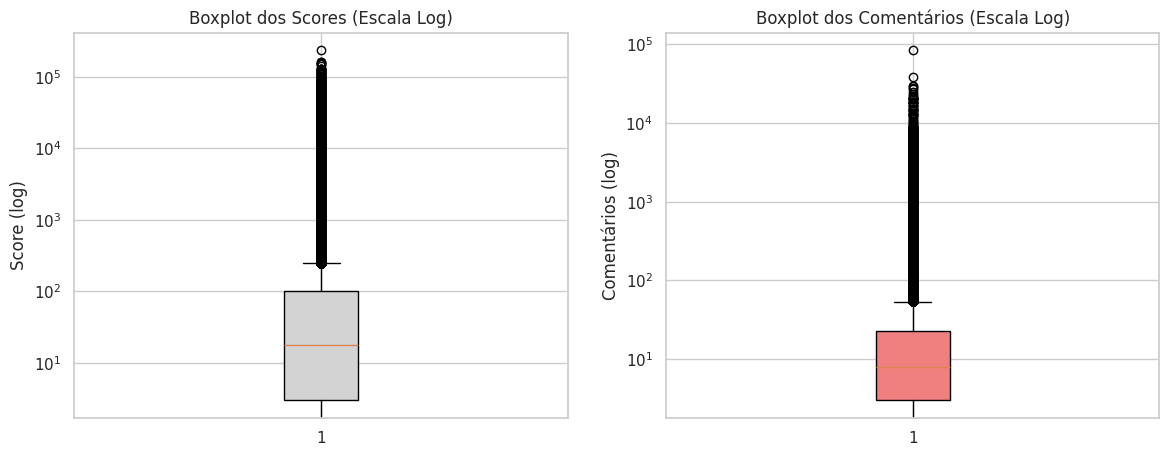

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df_limpo['score'], patch_artist=True, boxprops=dict(facecolor='lightgray'))
axes[0].set_yscale('log')
axes[0].set_title("Boxplot dos Scores (Escala Log)")
axes[0].set_ylabel("Score (log)")

axes[1].boxplot(df_limpo['commentsCount'], patch_artist=True, boxprops=dict(facecolor='lightcoral'))
axes[1].set_yscale('log')
axes[1].set_title("Boxplot dos Comentários (Escala Log)")
axes[1].set_ylabel("Comentários (log)")

plt.show()

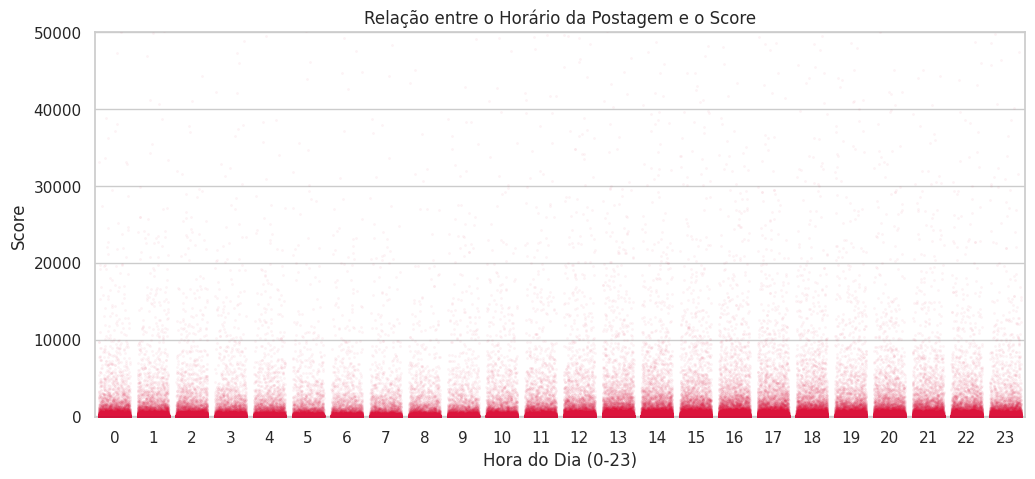

In [ ]:
plt.figure(figsize=(12, 5))
sns.stripplot(x='hora_num', y='score', data=df_limpo, alpha=0.05, jitter=0.4, color='crimson', size=2)
plt.title('Relação entre o Horário da Postagem e o Score')
plt.xlabel('Hora do Dia (0-23)')
plt.ylabel('Score')
plt.ylim(-100, 50000) 
plt.show()

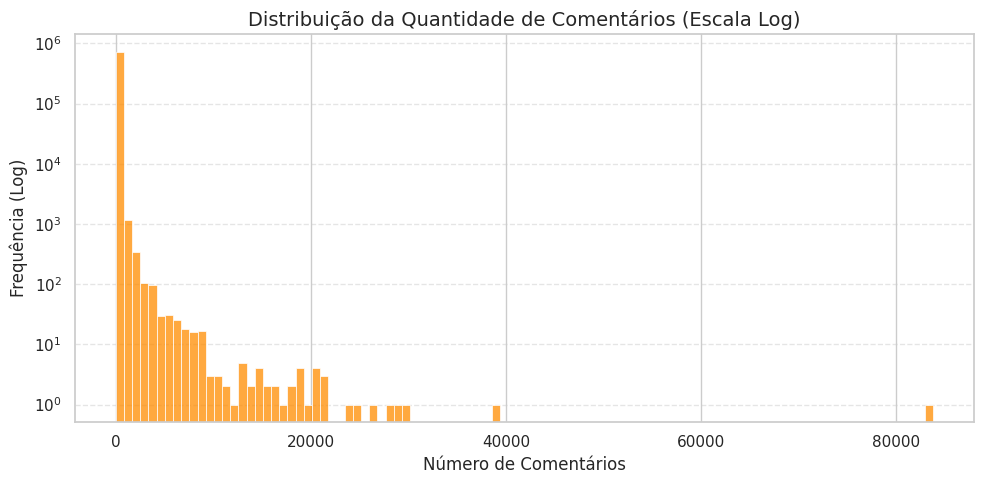

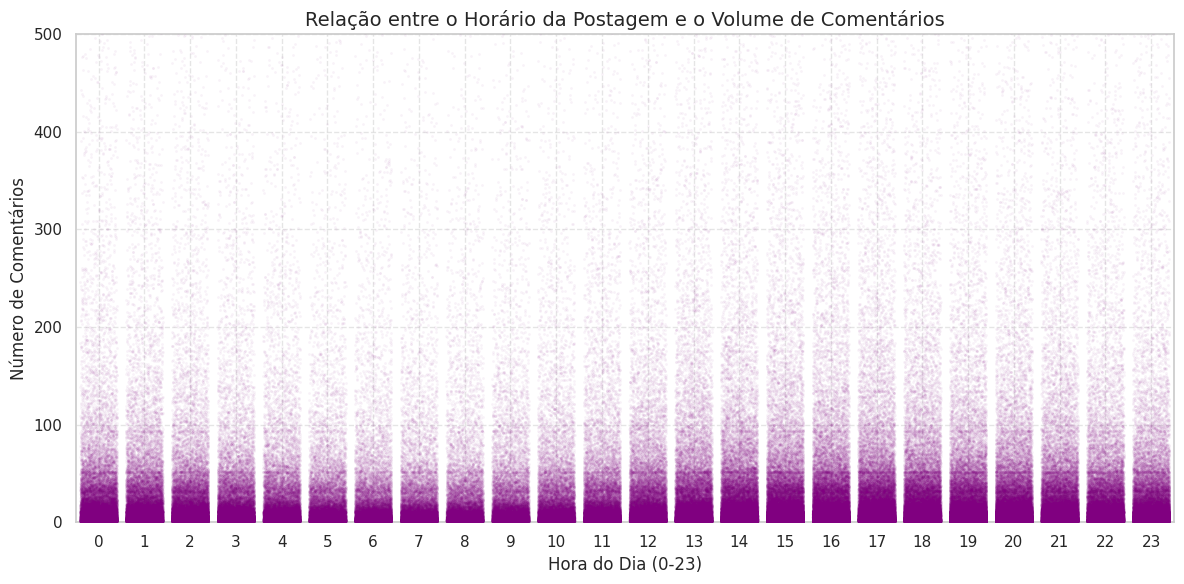

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df['commentsCount'] = pd.to_numeric(df['commentsCount'], errors='coerce')

dados_limpos = df.dropna(subset=['commentsCount'])

plt.figure(figsize=(10, 5))
sns.histplot(dados_limpos['commentsCount'], bins=100, color='darkorange', kde=False)

plt.title('Distribuição da Quantidade de Comentários (Escala Log)', fontsize=14)
plt.xlabel('Número de Comentários', fontsize=12)
plt.ylabel('Frequência (Log)', fontsize=12)
plt.yscale('log') 
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))

sns.stripplot(
    x='hora_num', 
    y='commentsCount', 
    data=df, 
    alpha=0.05, 
    jitter=0.4, 
    color='purple',
    size=2
)

plt.title('Relação entre o Horário da Postagem e o Volume de Comentários', fontsize=14)
plt.xlabel('Hora do Dia (0-23)', fontsize=12)
plt.ylabel('Número de Comentários', fontsize=12)
plt.ylim(0, 500)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

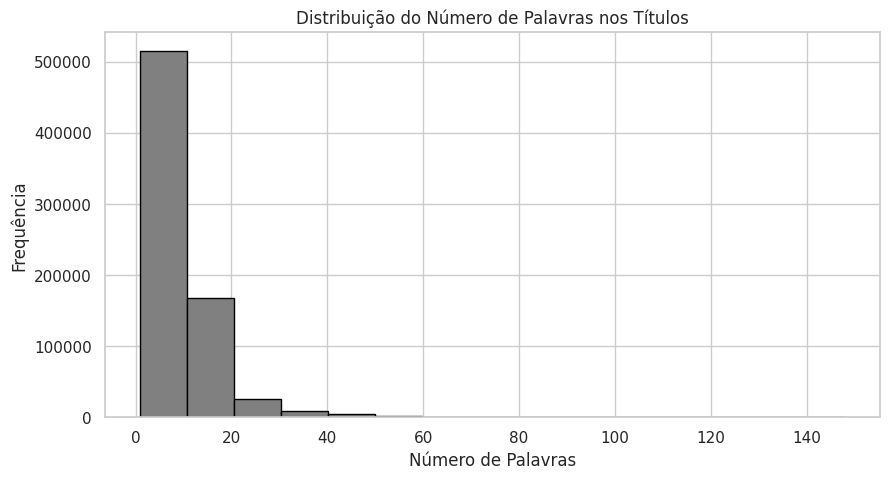

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(df_limpo['titleSize'], bins=15, edgecolor='black', facecolor='gray')
plt.title('Distribuição do Número de Palavras nos Títulos')
plt.xlabel('Número de Palavras')
plt.ylabel('Frequência')
plt.show()

In [ ]:
print(df[['data', 'hora_exata']].astype(str).describe())
print(df[['hora_num']].describe())

              data hora_exata
count       723514     723514
unique        3066      86250
top     2026-04-02   17:36:53
freq         68631         28
            hora_num
count  723514.000000
mean       12.692183
std         7.053000
min         0.000000
25%         6.000000
50%        14.000000
75%        19.000000
max        23.000000


## 7. Análise Topológica da Rede (Autores e Subreddits)

/tmp/ipykernel_65590/2561910240.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_subreddits.values, y=top_subreddits.index, palette='viridis', ax=axes[0])
/tmp/ipykernel_65590/2561910240.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_autores.values, y=top_autores.index, palette='magma', ax=axes[1])


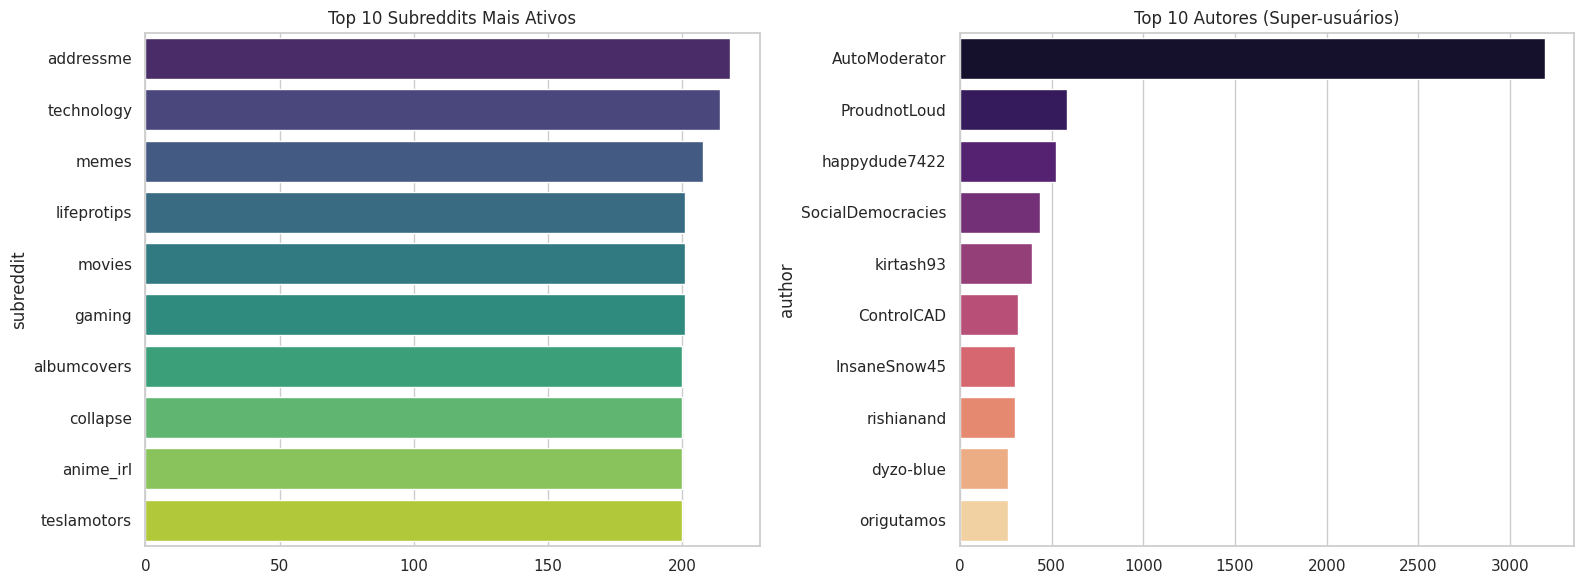

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_subreddits = df['subreddit'].value_counts().head(10)
sns.barplot(x=top_subreddits.values, y=top_subreddits.index, palette='viridis', ax=axes[0])
axes[0].set_title('Top 10 Subreddits Mais Ativos')

top_autores = df['author'].value_counts().head(10)
sns.barplot(x=top_autores.values, y=top_autores.index, palette='magma', ax=axes[1])
axes[1].set_title('Top 10 Autores (Super-usuários)')

plt.tight_layout()
plt.show()

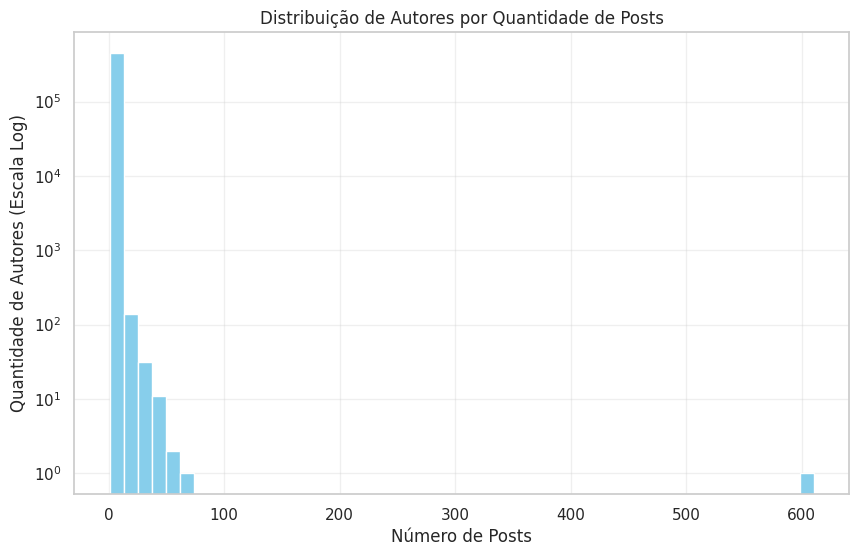

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

distintos_por_autor = df.groupby('author')['subreddit'].nunique()

plt.figure(figsize=(10, 6))
plt.hist(distintos_por_autor, bins=50, color='skyblue')
plt.yscale('log')
plt.xlabel("Número de Posts")
plt.ylabel("Quantidade de Autores (Escala Log)")
plt.title("Distribuição de Autores por Quantidade de Posts")
plt.grid(True, alpha=0.3)
plt.show()

## 8. Correlação entre Atributos
Para basear a futura modelagem preditiva, verificamos se as variáveis possuem relações lineares fortes entre si.

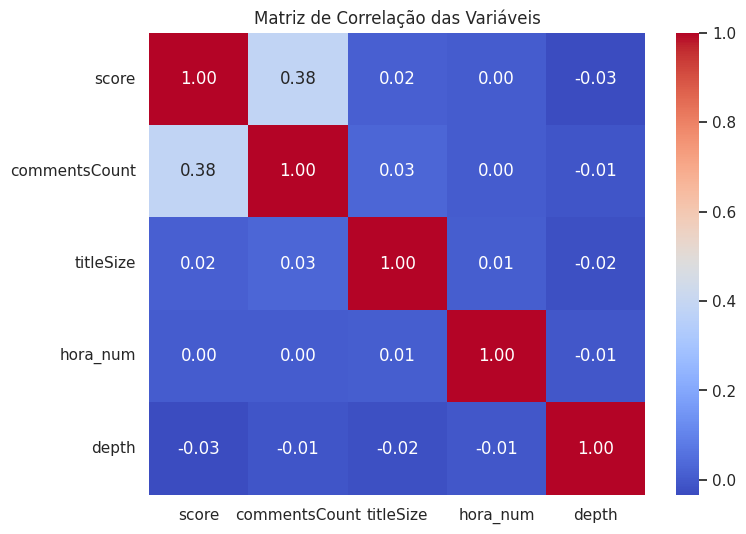

In [ ]:
colunas_numericas = ['score', 'commentsCount', 'titleSize', 'hora_num', 'depth']
matriz_correlacao = df_limpo[colunas_numericas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação das Variáveis")
plt.show()

In [ ]:
x = df.groupby("subreddit").size().sort_values(ascending=False)
x.describe()

count    4387.000000
mean      164.922270
std        45.516939
min         1.000000
25%       157.000000
50%       182.000000
75%       194.000000
max       218.000000
dtype: float64

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

bins_hora = [-1, 5, 11, 17, 23]
labels_hora = ['Madrugada', 'Manhã', 'Tarde', 'Noite']
df_limpo['periodo_dia'] = pd.cut(df_limpo['hora_num'], bins=bins_hora, labels=labels_hora)

df_limpo['engajamento_cat'] = df_limpo['score'].apply(lambda x: 'Alto' if x > 18 else 'Baixo')

tabela_contingencia = pd.crosstab(df_limpo['periodo_dia'], df_limpo['engajamento_cat'])

print("--- TABELA DE CONTINGÊNCIA: Período vs Engajamento ---")
print(tabela_contingencia)

chi2, p_valor, dof, expected = chi2_contingency(tabela_contingencia)

print(f"\nResultado do Teste Qui-Quadrado:")
print(f"Estatística Chi2: {chi2:.4f}")
print(f"P-Valor: {p_valor:.4e}")

if p_valor < 0.05:
    print("Conclusão: HÁ UMA RELAÇÃO ESTATISTICAMENTE SIGNIFICATIVA. O período do dia influencia a chance de um post ter alto engajamento.")
else:
    print("Conclusão: NÃO HÁ RELAÇÃO SIGNIFICATIVA. O engajamento independe do período do dia.")

--- TABELA DE CONTINGÊNCIA: Período vs Engajamento ---
engajamento_cat    Alto   Baixo
periodo_dia                    
Madrugada         79296   83543
Manhã             55919   60421
Tarde            112423  107522
Noite            111052  113338

Resultado do Teste Qui-Quadrado:
Estatística Chi2: 365.4984
P-Valor: 6.5706e-79
Conclusão: HÁ UMA RELAÇÃO ESTATISTICAMENTE SIGNIFICATIVA. O período do dia influencia a chance de um post ter alto engajamento.


## 9. Análise Temporal

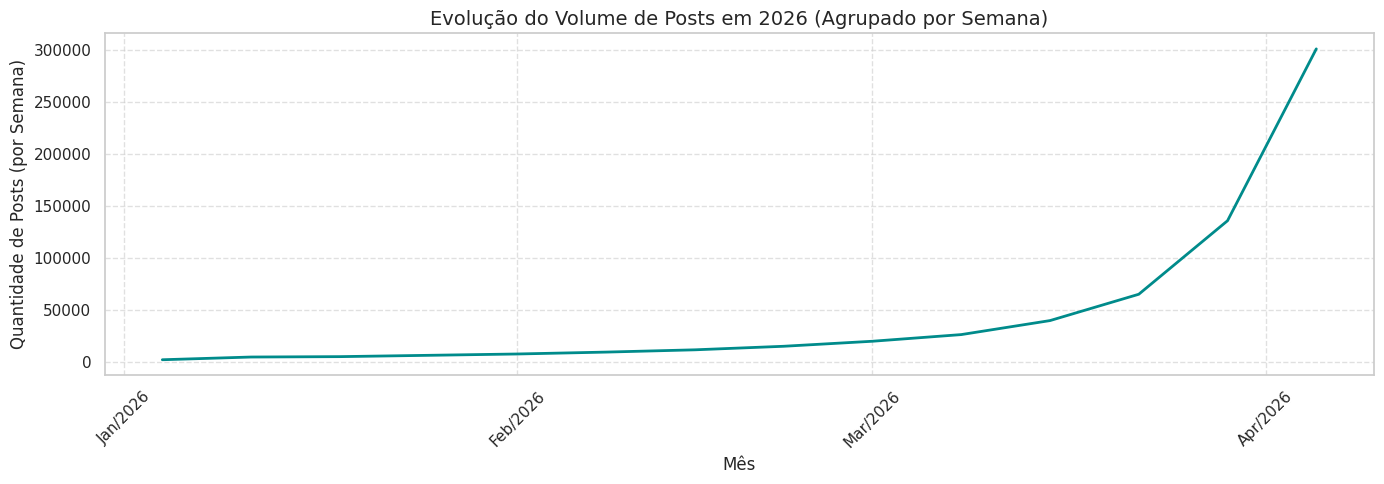

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import pandas as pd

df_2026 = df_limpo[df_limpo['timestamp'].dt.year == 2026].copy()

posts_por_semana = df_2026.set_index('timestamp').resample('W').size()

plt.figure(figsize=(14, 5))
sns.lineplot(x=posts_por_semana.index, y=posts_por_semana.values, color='darkcyan', linewidth=2)

plt.title('Evolução do Volume de Posts em 2026 (Agrupado por Semana)', fontsize=14)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Quantidade de Posts (por Semana)', fontsize=12)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))

plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

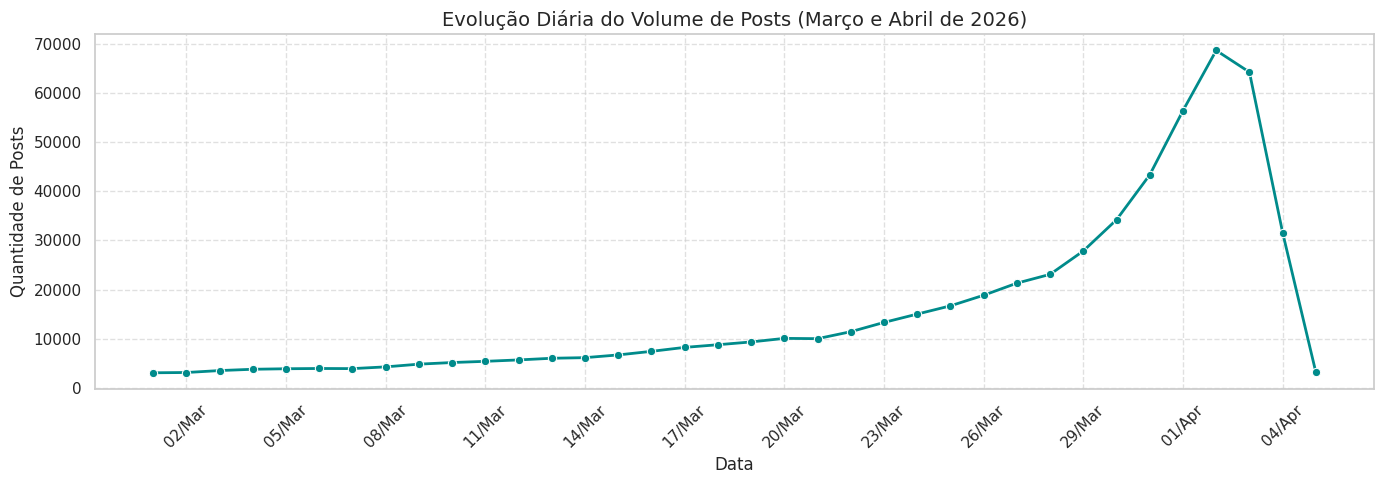

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import pandas as pd

df_mar_abr = df_limpo[
    (df_limpo['timestamp'].dt.year == 2026) & 
    (df_limpo['timestamp'].dt.month.isin([3, 4]))
].copy()

posts_por_dia = df_mar_abr.groupby('data').size()

plt.figure(figsize=(14, 5))

sns.lineplot(
    x=posts_por_dia.index, 
    y=posts_por_dia.values, 
    color='darkcyan', 
    linewidth=2, 
    marker='o'
)

plt.title('Evolução Diária do Volume de Posts (Março e Abril de 2026)', fontsize=14)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Quantidade de Posts', fontsize=12)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%b'))

plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
display(df_limpo)
df_limpo.to_csv("df_kdd.csv", index=False)

,id,title,author,subreddit,timestamp,score,comments_text,url,depth,titleSize,...,tem_url,commentsCount,data,hora_exata,hora_num,relevante,score_norm,commentsCount_norm,titleSize_norm,titleChars_norm
0,t3_2nj2ed,My compilation of posts on why TRP is sexist a...,IAmAN00bie,thebluepill,2014-11-27 00:04:59+00:00,866,224 comments,/r/TheBluePill/comments/2nj2ed/my_compilation_...,0,16,...,0,224.0,2014-11-27,00:04:59,0,True,0.003669,0.002672,0.102041,0.250836
1,t3_1rw6rcv,"Looking for anonymous interviewees in Quebec, ...",Huge-Guidance-6068,thebluepill,2026-03-17 13:37:32+00:00,1,1 comment,/r/TheBluePill/comments/1rw6rcv/looking_for_an...,0,7,...,0,1.0,2026-03-17,13:37:32,13,False,0.000004,0.000012,0.040816,0.170569
2,t3_1rf56ft,forensic psychology research,SecurityGreedy4928,thebluepill,2026-02-26 08:52:58+00:00,3,1 comment,/r/TheBluePill/comments/1rf56ft/forensic_psych...,0,3,...,0,1.0,2026-02-26,08:52:58,8,False,0.000013,0.000012,0.013605,0.090301
5,t3_1r0rsyw,How do I get over being redpilled for 5 years ...,De_lunes_a_lunes,thebluepill,2026-02-10 05:03:47+00:00,128,46 comments,/r/TheBluePill/comments/1r0rsyw/how_do_i_get_o...,0,13,...,0,46.0,2026-02-10,05:03:47,5,True,0.000542,0.000549,0.081633,0.193980
7,t3_1qwhmr9,Derek from More Plates More Dates & Gorilla Mi...,Numerous-Rule3947,thebluepill,2026-02-05 10:19:45+00:00,14,2 comments,/r/TheBluePill/comments/1qwhmr9/derek_from_mor...,0,21,...,0,2.0,2026-02-05,10:19:45,10,False,0.000059,0.000024,0.136054,0.414716
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
843853,t3_1q0hss6,Persecution and Violence and Accountability,None,weaponsmovie,2025-12-31 17:00:31+00:00,9,11 comments,/r/WeaponsMovie/comments/1q0hss6/persecution_a...,2,5,...,0,11.0,2025-12-31,17:00:31,17,False,0.000038,0.000131,0.027211,0.140468
843854,t3_1pxgijo,Archer’s Dream question,AlphabeticalTraveler,weaponsmovie,2025-12-28 03:07:00+00:00,27,8 comments,/r/WeaponsMovie/comments/1pxgijo/archers_dream...,2,3,...,0,8.0,2025-12-28,03:07:00,3,False,0.000114,0.000095,0.013605,0.073579
843855,t3_1pwjxwe,was watching Uncle Buck (1989) and,onlyif_foranight,weaponsmovie,2025-12-27 00:40:46+00:00,649,39 comments,https://www.reddit.com/gallery/1pwjxwe,2,6,...,0,39.0,2025-12-27,00:40:46,0,False,0.002750,0.000465,0.034014,0.110368
843856,t3_1pvgi1p,Merry Crisis from your loving auntie!,BluePlanet10,weaponsmovie,2025-12-25 16:09:41+00:00,477,8 comments,https://i.redd.it/hjfmghfnjd9g1.jpeg,2,6,...,0,8.0,2025-12-25,16:09:41,16,False,0.002021,0.000095,0.034014,0.120401
